# Credit Scoring: прогнозирование риска невозврата кредита
## Цель: Продемонстрировать навыки обработки данных и создания моделей классификации
### Бизнес-контекст: Должны заранее знать кто из наших потенциальных заемщиков вернет кредит а кто нет и на основе этого выдавать кредит

In [1]:
%pip install xgboost lightgbm shap lime -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import sklearn
import plotly
from matplotlib import pyplot as plt
import catboost
import xgboost as xgb
import lightgbm as lgb
import shap
from lime import lime_tabular
import seaborn as sns

c:\Users\morro\anaconda3\envs\autotopic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_train = pd.read_csv("./cs-training.csv")
X_test = pd.read_csv("./cs-test.csv")

# EDA

General information

In [4]:
print('train:', X_train.shape)
print('test:', X_test.shape)
print('\n', X_train.dtypes)
print('\n', X_train.isna().sum())
print('\n', X_train.head(10))

train: (150000, 12)
test: (101503, 12)

 Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

 Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0

Target analysis

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


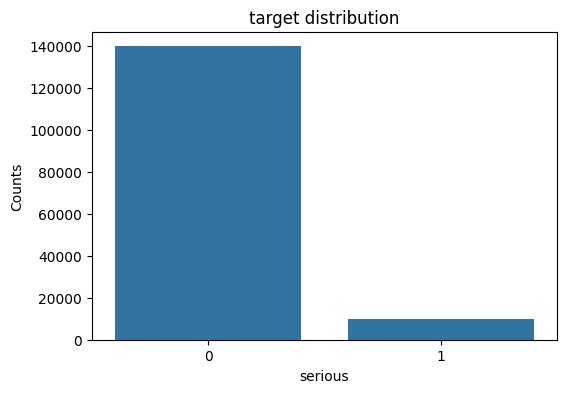

In [5]:
class_counter = X_train['SeriousDlqin2yrs'].value_counts()
print(class_counter)

class_percent = X_train['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print(class_percent)

plt.figure(figsize=(6,4))
sns.countplot(x='SeriousDlqin2yrs', data=X_train)
plt.title('target distribution')
plt.xlabel('serious')
plt.ylabel('Counts')
plt.show()

In [6]:
X_train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


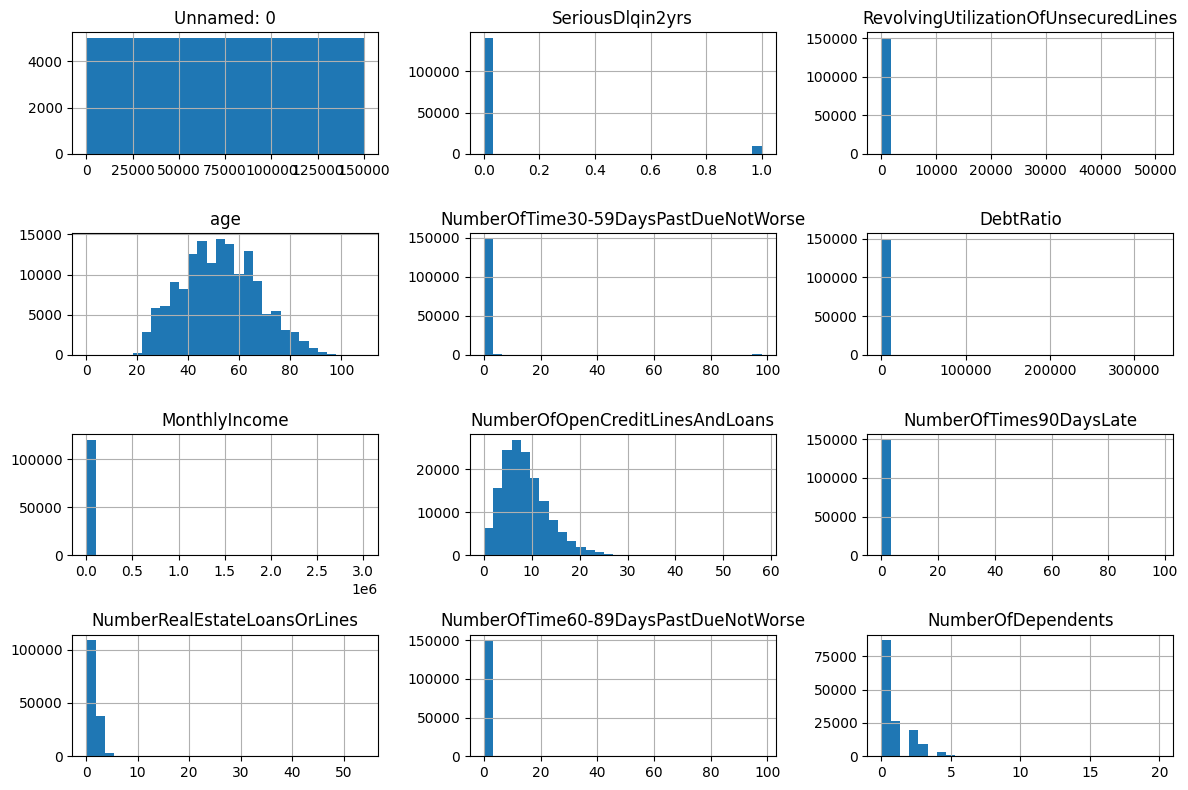

In [7]:
X_train.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

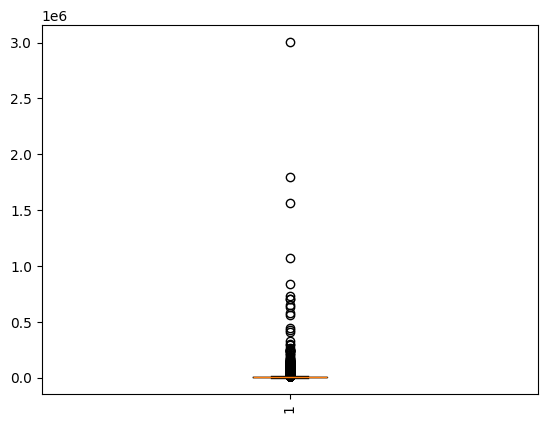

In [8]:
plt.boxplot(X_train['MonthlyIncome'].dropna())
plt.xticks(rotation=90)
plt.show()

In [9]:
print('sda')

sda


In [10]:
corr = X_train.corr(numeric_only=True)
print(corr)

                                      Unnamed: 0  SeriousDlqin2yrs  \
Unnamed: 0                              1.000000          0.002801   
SeriousDlqin2yrs                        0.002801          1.000000   
RevolvingUtilizationOfUnsecuredLines    0.002372         -0.001802   
age                                     0.004403         -0.115386   
NumberOfTime30-59DaysPastDueNotWorse   -0.000571          0.125587   
DebtRatio                              -0.002906         -0.007602   
MonthlyIncome                           0.002632         -0.019746   
NumberOfOpenCreditLinesAndLoans         0.004586         -0.029669   
NumberOfTimes90DaysLate                -0.001104          0.117175   
NumberRealEstateLoansOrLines           -0.000666         -0.007038   
NumberOfTime60-89DaysPastDueNotWorse   -0.000777          0.102261   
NumberOfDependents                     -0.000055          0.046048   

                                      RevolvingUtilizationOfUnsecuredLines  \
Unnamed: 0 

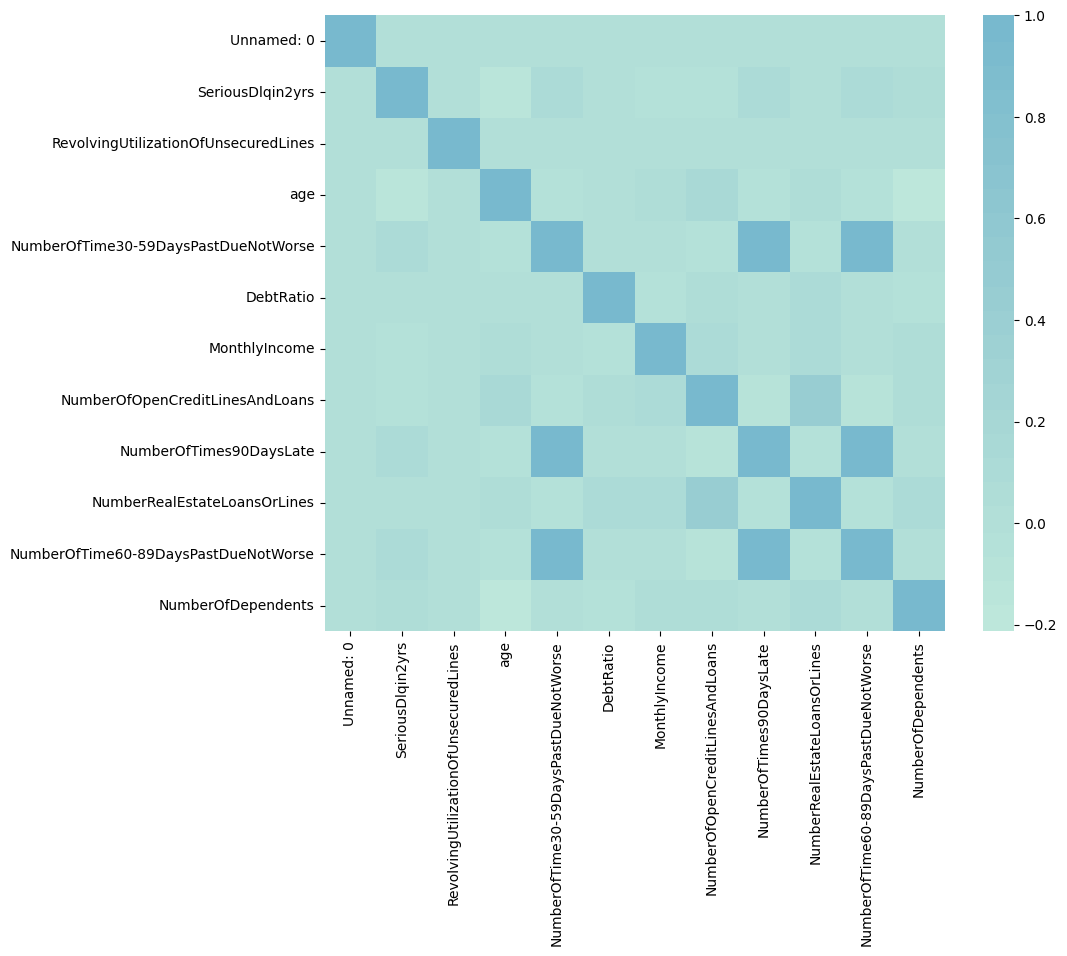

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, center=6)
plt.show()

In [12]:
target_corr = corr['SeriousDlqin2yrs'].sort_values(ascending=False)
print(target_corr)

strong_features = target_corr[target_corr.abs() > .1].index.drop('SeriousDlqin2yrs')

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
Unnamed: 0                              0.002801
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


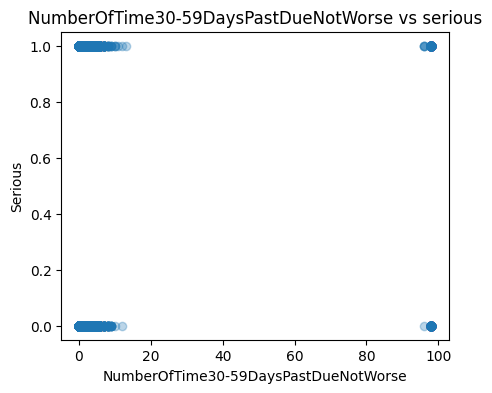

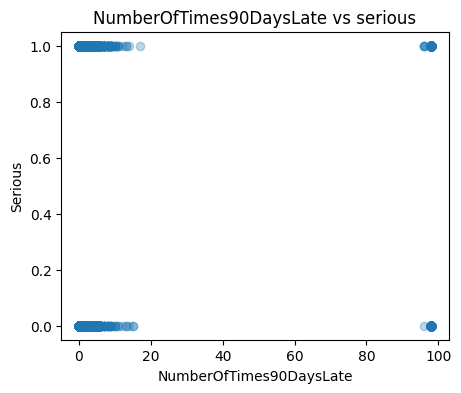

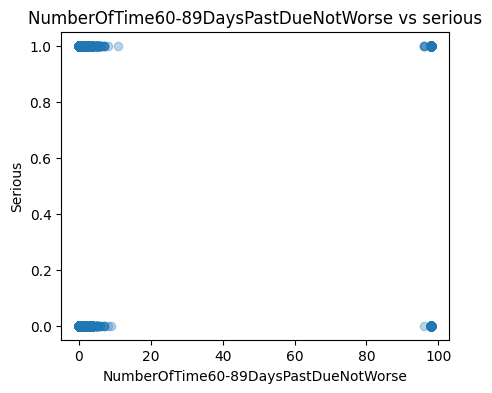

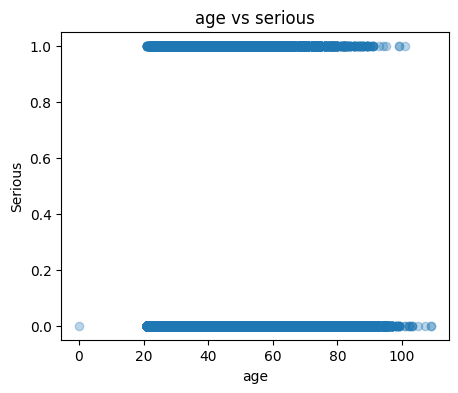

In [13]:
for feature in strong_features:
    plt.figure(figsize=(5,4))
    plt.scatter(X_train[feature], X_train['SeriousDlqin2yrs'], alpha=.3)
    plt.xlabel(feature)
    plt.ylabel('Serious')
    plt.title(f'{feature} vs serious')
    plt.show()

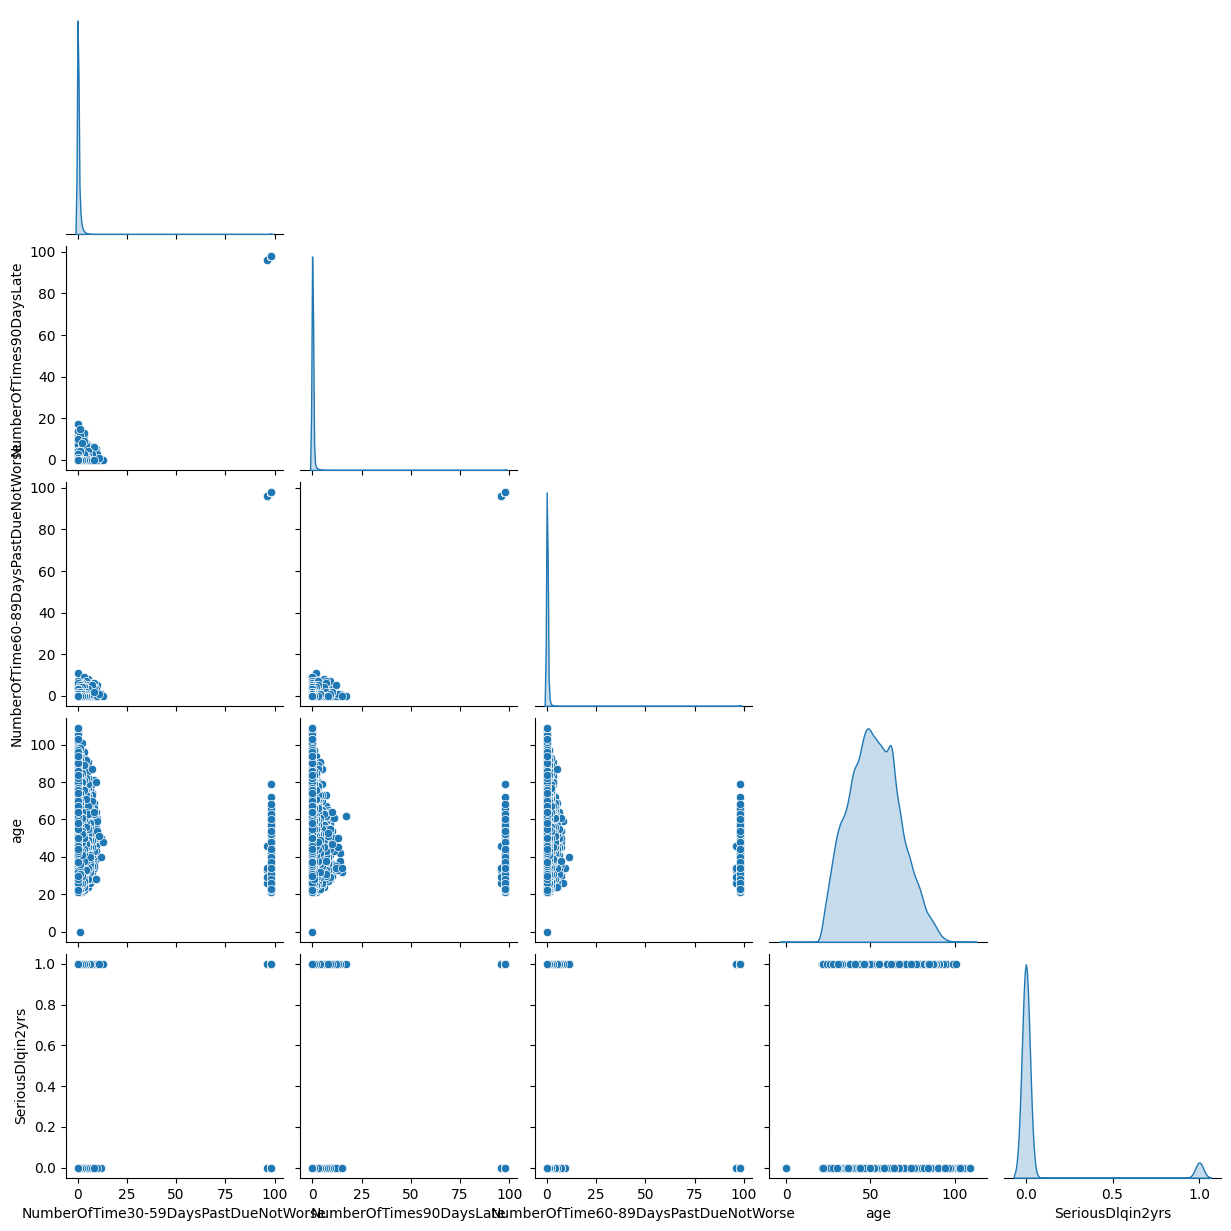

In [14]:
# можно добавить таргет как hue
sns.pairplot(X_train[list(strong_features) + ['SeriousDlqin2yrs']], corner=True, diag_kind='kde')
plt.show()

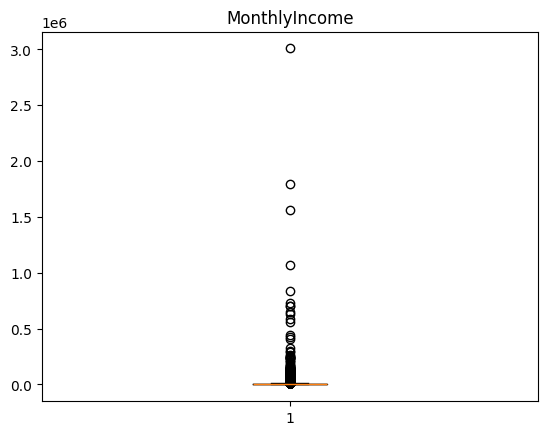

In [15]:
plt.boxplot(X_train['MonthlyIncome'].dropna())
plt.title('MonthlyIncome')
plt.show()

# Data preprocessing

## Missing values

In [16]:
X_train = X_train[X_train['age'] >= 18]

age_groups = pd.cut(X_train['age'], bins=[18, 30, 45, 60, 100])

departments_mode = X_train['NumberOfDependents'].mode()[0]
X_train['NumberOfDependents'] = X_train['NumberOfDependents'].fillna(departments_mode)

## Outliers

In [17]:
grouped_medians = X_train.groupby(age_groups)['MonthlyIncome'].transform('median')
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(grouped_medians)

# Winsorization
lower_bound = X_train['MonthlyIncome'].quantile(.01)
upper_bound = X_train['MonthlyIncome'].quantile(.99)

X_train['MonthlyIncome'] = X_train['MonthlyIncome'].clip(lower=lower_bound, upper=upper_bound)

C:\Users\morro\AppData\Local\Temp\ipykernel_17060\2310283793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_medians = X_train.groupby(age_groups)['MonthlyIncome'].transform('median')


In [18]:
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].mask(X_train['NumberOfTime30-59DaysPastDueNotWorse'] > 20, 20)

In [19]:
upper_debt = X_train['DebtRatio'].quantile(0.95) 

# 2. Обрезаем значения (clipping)
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=upper_debt)
X_test['DebtRatio'] = X_test['DebtRatio'].clip(upper=upper_debt) # Используем границу от Train!

# 3. Логарифмируем, так как распределение все равно смещено
X_train['DebtRatio'] = np.log1p(X_train['DebtRatio'])
X_test['DebtRatio'] = np.log1p(X_test['DebtRatio'])

## Feature Engeneering

In [20]:
X_train['IsRetired'] = (X_train['age'] > 65).astype(int)
X_test['IsRetired'] = (X_test['age'] > 65).astype(int)


X_train['IncomePerPerson'] = X_train['MonthlyIncome'] / (X_train['NumberOfDependents'] + 1)
X_test['IncomePerPerson'] = X_test['MonthlyIncome'] / (X_test['NumberOfDependents'] + 1)

In [21]:
X_train['Log_OpenLines'] = np.log1p(X_train['NumberOfOpenCreditLinesAndLoans'])
X_test['Log_OpenLines'] = np.log1p(X_test['NumberOfOpenCreditLinesAndLoans'])

X_train['Log_MonthlyIncome'] = np.log1p(X_train['MonthlyIncome'])
X_test['Log_MonthlyIncome'] = np.log1p(X_test['MonthlyIncome'])

X_train['IncomePerPerson'] = np.log1p(X_train['IncomePerPerson'])
X_test['IncomePerPerson'] = np.log1p(X_test['IncomePerPerson'])



In [22]:
cols_to_sum = [
    'NumberOfTime30-59DaysPastDueNotWorse', 
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfTimes90DaysLate'
]

for df in [X_train, X_test]:
    df['CombinedDefault'] = df[cols_to_sum].sum(axis=1)

In [23]:
# Заполняем оставшиеся 3 пропуска общей медианой
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(X_train['MonthlyIncome'].median())

# После этого пересчитаем зависимые признаки, чтобы в них тоже не было NaN
X_train['IncomePerPerson'] = X_train['MonthlyIncome'] / (X_train['NumberOfDependents'] + 1)
X_train['Log_MonthlyIncome'] = np.log1p(X_train['MonthlyIncome'])

## Train test split 80/20 stratif.

In [24]:
from sklearn.model_selection import train_test_split

X = X_train.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'], errors='ignore')
y = X_train['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  
    random_state=42, 
    stratify=y           
)

## Scale (for log reg)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model 

In [26]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
y_pred = log_reg.predict(X_test_scaled)

y_probs_all = log_reg.predict_proba(X_test_scaled)

y_probs = y_probs_all[:, 1]

              precision    recall  f1-score   support

           0       0.97      0.81      0.89     27995
           1       0.20      0.67      0.31      2005

    accuracy                           0.80     30000
   macro avg       0.59      0.74      0.60     30000
weighted avg       0.92      0.80      0.85     30000



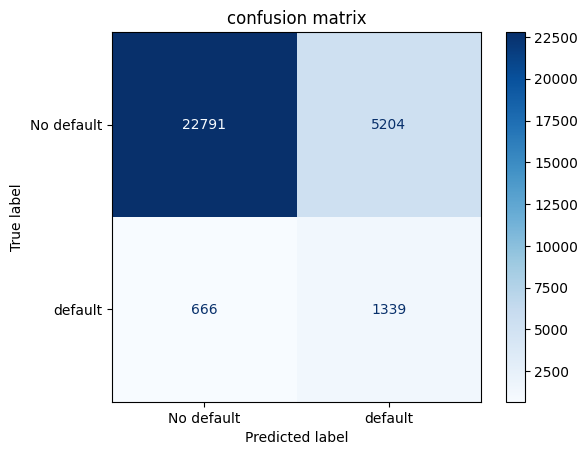

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No default', 'default'])
disp.plot(cmap='Blues')
plt.title('confusion matrix')
plt.show()



ROC-AUC Score: 0.8054


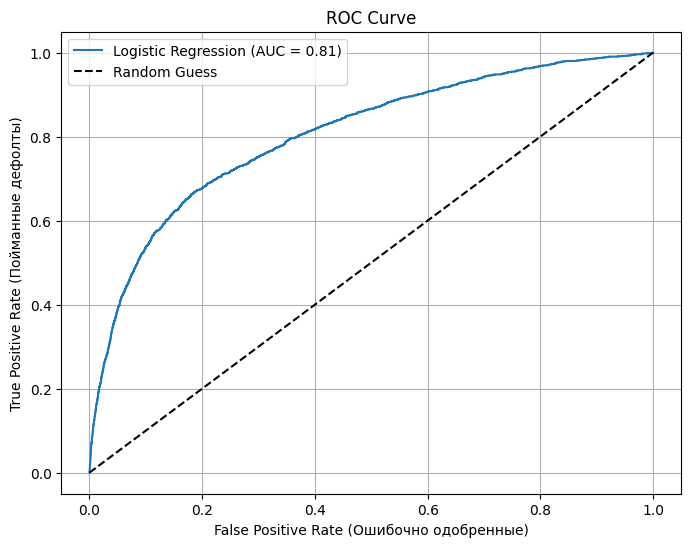

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_value = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_value:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (Ошибочно одобренные)')
plt.ylabel('True Positive Rate (Пойманные дефолты)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

## Hard models (xgb, catboost, random_forest)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=43,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=.1,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=43,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(roc_auc_score(y_test, rf_probs))
print(roc_auc_score(y_test, xgb_probs))

0.8361380260725219
0.5580308471543057


c:\Users\morro\anaconda3\envs\autotopic\lib\site-packages\xgboost\training.py:199: UserWarning: [18:00:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train_scaled, y_train)
cat_probs = cat_model.predict_proba(X_test_scaled)[:, 1]

print(roc_auc_score(y_test, cat_probs))

0.8693655573514864


In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_model = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=43
)

random_search.fit(X_train_scaled, y_train)
best_xgb = random_search.best_estimator_
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


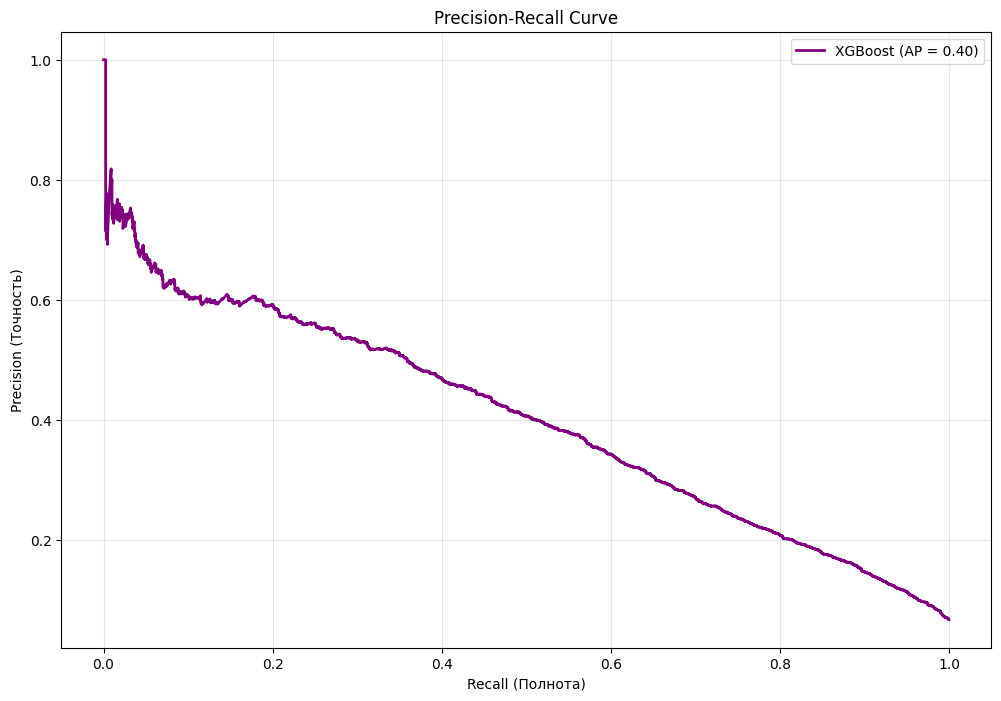

0.8700073801921344


In [33]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

y_probs_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_best)
avg_precision = average_precision_score(y_test, y_probs_best)


plt.figure(figsize=(12, 8))
plt.plot(recall, precision, label=f'XGBoost (AP = {avg_precision:.2f})', color='purple', lw=2)
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

print(roc_auc_score(y_test, y_probs_best))

# Model Interpretation

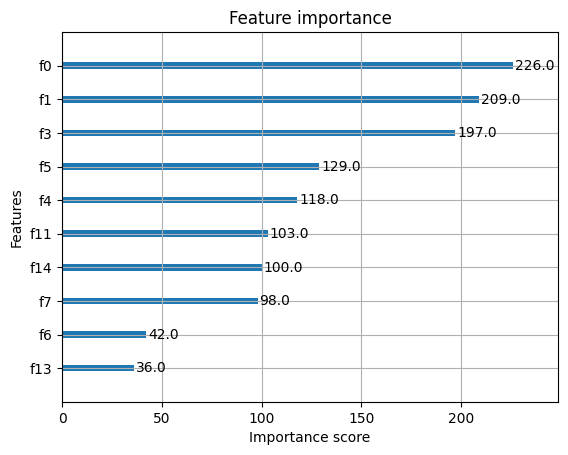

In [34]:
xgb.plot_importance(best_xgb, max_num_features=10)
plt.show()

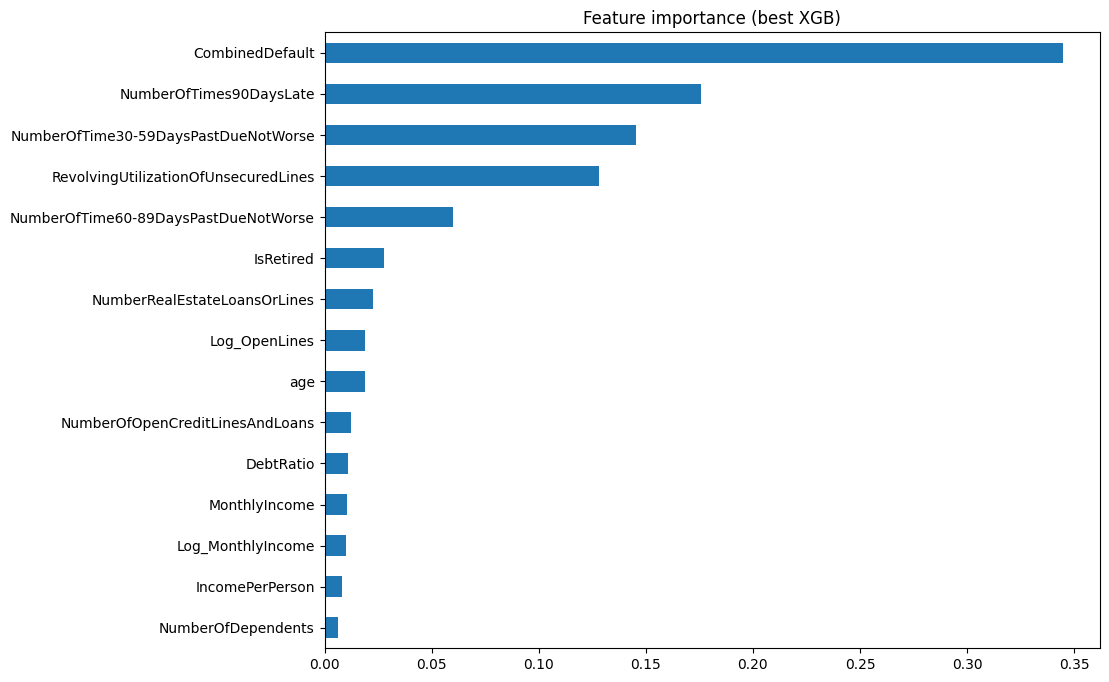

In [35]:
importance = pd.Series(best_xgb.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Feature importance (best XGB)')
plt.show()

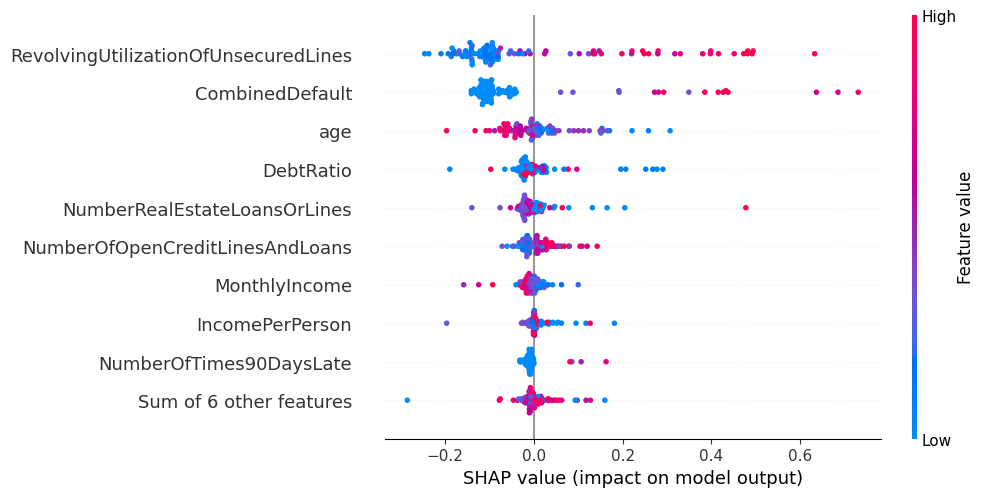

In [36]:
import shap
import pandas as pd

# 1. Подготовим данные в формате DataFrame (это ВАЖНО для нормального графика)
X_display = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. Используем Explainer с маскировщиком (masker)
# Мы даем модели фоновые данные, чтобы она знала, с чем сравнивать
# 100 случайных примеров из трейна — это золотой стандарт для "фона"
background = shap.maskers.Independent(X_train_scaled, max_samples=100)

# 3. Инициализируем Explainer для функции predict (или predict_proba)
# Это обходит внутренний XGBTreeModelLoader и его любовь к base_score
explainer = shap.Explainer(best_xgb.predict, background)

# 4. Считаем SHAP-значения для 100 человек (считает быстро)
X_sample = X_display.iloc[:100]
shap_values = explainer(X_sample)

# 5. Рисуем полноценный beeswarm
# Теперь он подтянет ВСЕ признаки из DataFrame
shap.plots.beeswarm(shap_values)

# Financial Impact

In [39]:
import pandas as pd
import numpy as np
import shap

# 1. Создаем эксплейнер ОДИН РАЗ вне функции (используем стабильный метод)
# Передаем маскировщик, чтобы избежать проблем с парсингом JSON
background = shap.maskers.Independent(X_train_scaled, max_samples=100)
explainer_fixed = shap.Explainer(best_xgb.predict, background)

def explain_decision_fixed(client_index, X_data, model, feature_names, explainer):
    """
    client_index: индекс клиента из тестового набора
    X_data: DataFrame с тестовыми данными (X_test_scaled)
    """
    # Выделяем данные одного клиента
    client_row = X_data.iloc[client_index : client_index + 1]
    
    # 1. Считаем вероятность
    prob = model.predict_proba(client_row)[0][1]
    
    # 2. Получаем SHAP-значения через заранее созданный эксплейнер
    shap_output = explainer(client_row)
    
    # Собираем данные в таблицу для анализа
    contributions = pd.DataFrame({
        'feature': feature_names,
        'influence': shap_output.values[0],
        'value': client_row.values[0]
    })
    
    # Сортируем по силе влияния
    contributions = contributions.sort_values(by='influence', ascending=False)

    print(f"--- АНАЛИЗ ЗАЯВКИ (Клиент №{client_index}) ---")
    print(f"Вероятность дефолта: {prob:.2%}")
    print(f"Вердикт: {'ОТКАЗАТЬ' if prob > 0.5 else 'ОДОБРИТЬ'}")
    
    print("\nТоп-3 фактора:")
    for _, row in contributions.iloc[np.abs(contributions['influence']).argsort()[-3:][::-1]].iterrows():
        status = "повышает риск 🚩" if row['influence'] > 0 else "снижает риск ✅"
        print(f"• {row['feature']}: {row['value']:.2f} -> {status}")

# --- ЗАПУСК ---
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
explain_decision_fixed(123, X_test_df, best_xgb, X.columns, explainer_fixed)

--- АНАЛИЗ ЗАЯВКИ (Клиент №123) ---
Вероятность дефолта: 87.02%
Вердикт: ОТКАЗАТЬ

Топ-3 фактора:
• CombinedDefault: 0.24 -> повышает риск 🚩
• RevolvingUtilizationOfUnsecuredLines: -0.02 -> повышает риск 🚩
• NumberOfOpenCreditLinesAndLoans: 1.07 -> повышает риск 🚩


In [82]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Получаем вероятности (а не классы)
y_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 2. Устанавливаем новый порог 0.3
new_threshold = 0.735
y_pred_new = (y_probs >= new_threshold).astype(int)

# 3. Выводим результаты
print(f"--- Результаты для порога {new_threshold} ---")
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

--- Результаты для порога 0.735 ---
[[26084  1911]
 [  874  1131]]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27995
           1       0.37      0.56      0.45      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.75      0.70     30000
weighted avg       0.93      0.91      0.92     30000



In [83]:
def calculate_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Мы зарабатываем на тех, кому предсказали 0 и они реально 0 (TN)
    # Мы теряем на тех, кому предсказали 0, а они ушли в дефолт (FN)
    # Тем, кому предсказали 1 (FP и TP), мы просто не даем кредит (0 прибыли/убытка)
    total_profit = (tn * 2000) - (fn * 10000)
    return total_profit

# Считаем для "Одобряем всем" (все предсказания = 0)
y_all_zero = np.zeros_like(y_test)
profit_all = calculate_profit(y_test, y_all_zero)

# Считаем для модели (порог 0.3)
profit_model = calculate_profit(y_test, y_pred_new)

print(f"Прибыль без модели: ${profit_all:,}")
print(f"Прибыль с твоим XGBoost: ${profit_model:,}")
print(f"Чистый выигрыш от внедрения ML: ${profit_model - profit_all:,}")

Прибыль без модели: $35,940,000
Прибыль с твоим XGBoost: $43,428,000
Чистый выигрыш от внедрения ML: $7,488,000
